In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.0+cu126
CUDA available: True


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Batch_Size = 64
LR = 0.001
Epochs = 10

print("Usinfg Device: ", device)

Usinfg Device:  cuda


In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root='C:\Study content\ML\DATASETS',
    train=True, download=True, 
    transform=transform
    )

test_dataset = datasets.MNIST(
    root='C:\Study content\ML\DATASETS',
    train=False,
    download=True,
    transform=transform
)


train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=Batch_Size, shuffle=False)        
print('Training samples:', len(train_dataset))
print('Test samples:', len(test_dataset))

Training samples: 60000
Test samples: 10000


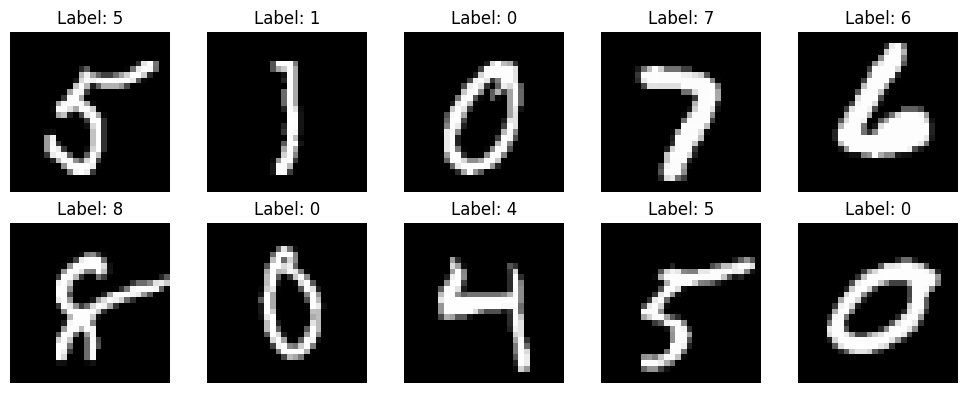

In [20]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [21]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [22]:
model = MLP().to(device)
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [23]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Trainable parameters:', total_params)

Trainable parameters: 109386


In [24]:
loss_fn = nn.CrossEntropyLoss()
optim = optim.Adam(model.parameters(), lr=LR)


In [25]:
train_loss=[]
train_acc=[]
test_loss=[]
test_acc=[]

for epoch in range(Epochs):
    model.train()
    running_loss = 0.0
    correct =0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optim.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optim.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validation/test evaluation
    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
  
            test_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_epoch_loss = test_running_loss / test_total
    test_epoch_acc = 100 * test_correct / test_total
    test_loss.append(test_epoch_loss)
    test_acc.append(test_epoch_acc)
    
    print(
            f'Epoch [{epoch+1}/{Epochs}] | '
            f'Train Loss: {epoch_loss:.4f} | '
            f'Train Acc: {epoch_acc:.2f}% | '
            f'Test Loss: {test_epoch_loss:.4f} | '
            f'Test Acc: {test_epoch_acc:.2f}%'
        )



Epoch [1/10] | Train Loss: 0.2722 | Train Acc: 91.97% | Test Loss: 0.1355 | Test Acc: 95.67%
Epoch [2/10] | Train Loss: 0.1117 | Train Acc: 96.54% | Test Loss: 0.0982 | Test Acc: 96.85%
Epoch [3/10] | Train Loss: 0.0774 | Train Acc: 97.61% | Test Loss: 0.0883 | Test Acc: 97.26%
Epoch [4/10] | Train Loss: 0.0599 | Train Acc: 98.11% | Test Loss: 0.0808 | Test Acc: 97.37%
Epoch [5/10] | Train Loss: 0.0470 | Train Acc: 98.50% | Test Loss: 0.1021 | Test Acc: 96.88%
Epoch [6/10] | Train Loss: 0.0404 | Train Acc: 98.61% | Test Loss: 0.0789 | Test Acc: 97.49%
Epoch [7/10] | Train Loss: 0.0334 | Train Acc: 98.90% | Test Loss: 0.0738 | Test Acc: 97.94%
Epoch [8/10] | Train Loss: 0.0277 | Train Acc: 99.08% | Test Loss: 0.0906 | Test Acc: 97.54%
Epoch [9/10] | Train Loss: 0.0229 | Train Acc: 99.25% | Test Loss: 0.0863 | Test Acc: 97.78%
Epoch [10/10] | Train Loss: 0.0229 | Train Acc: 99.20% | Test Loss: 0.0978 | Test Acc: 97.85%


In [26]:
###Model Evaluation
model.eval()
correct = 0
total = 0
images, labels = next(iter(test_loader))
images_device = images.to(device)
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total
print(f'Final Test Accuracy: {accuracy:.2f}%')

Final Test Accuracy: 97.85%


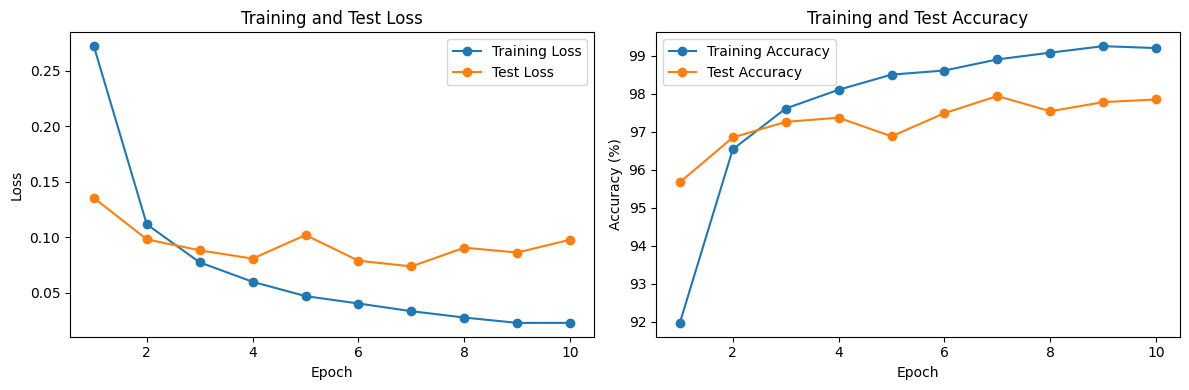

In [27]:
epochs_range = range(1, Epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, marker='o', label='Training Loss')
plt.plot(epochs_range, test_loss, marker='o', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, marker='o', label='Training Accuracy')
plt.plot(epochs_range, test_acc, marker='o', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

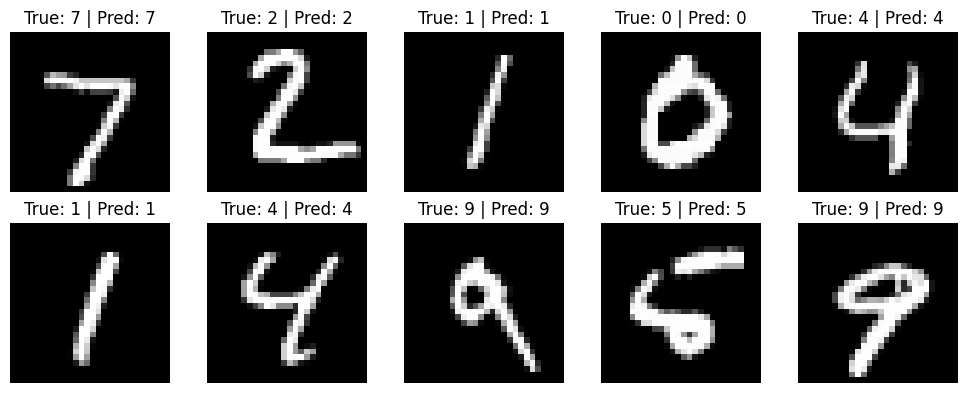

In [28]:
model.eval()
images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    predictions = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {labels[i].item()} | Pred: {predictions[i].item()}')
    ax.axis('off')

plt.tight_layout()
plt.show()